# Fraud detection — baseline model

CLAUDE.md §4. This notebook exists **before** the Kubeflow pipeline on purpose:
the pipeline's job is to run these steps repeatably, and there is no point
automating a sequence nobody has watched work once. Everything here is
deliberately explicit — the same steps become pipeline components in §5.

What it does:

1. pull point-in-time-correct features from the **Feast** offline store
2. join them to the fraud **label table** on `claim_id`
3. split **by time**, not at random
4. train a logistic-regression baseline
5. evaluate at a realistic operating point
6. save one `.joblib` artifact that carries its own preprocessing

It runs from a laptop against the deployed platform: features come from GCS via
the Feast SDK, so nothing here needs the cluster except the data it already
wrote. Redis is not touched — online serving is §1's problem, and a training
job that reads the online store would be reading features that have already
expired.

In [1]:
%matplotlib inline

import json
import sys
from pathlib import Path

import gcsfs
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from feast import FeatureStore

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
LAKEHOUSE = "gs://aide-playground-lakehouse"

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

print("python     :", sys.version.split()[0])
print("repo       :", REPO)

python     : 3.12.3
repo       : /home/qmai/FSDS/coursework/insurance_ai_de_engineering_project


## 1. Connect to the feature store

`repo_path` points at the same `feature_store/` directory the Airflow
Materialize Pipeline uses, so the registry, the offline paths and the TTLs are
read from one definition rather than restated here. That is the entire point of
a feature store: if this notebook re-derived the aggregates itself, the model
would be trained on features that no serving path could reproduce.

In [2]:
store = FeatureStore(repo_path=str(REPO / "feature_store"))

print("project    :", store.project)
print("registry   :", store.config.registry.path)
print("offline    :", store.config.offline_store.type)
for view in store.list_feature_views():
    print(
        f"  view {view.name:16s} entities={view.entities} "
        f"ttl={view.ttl.days}d features={len(view.features)}"
    )

project    : insurance_fraud
registry   : gs://aide-playground-lakehouse/feast/registry.db
offline    : file


  view claim_features   entities=['claim'] ttl=3650d features=14
  view customer_90d     entities=['customer'] ttl=120d features=5


## 2. The label table

`claim_labels` is generated as its own table (`jobs/insurance_data_generator.py`)
and read straight from Bronze. It never enters Gold or the feature views, and
that separation is not tidiness:

- a label is not a feature. It arrives later, from a different process — a
  fraud investigation closing weeks after the claim.
- anything in a feature view gets materialized into Redis, where the prediction
  API would happily read it. A label in the online store is target leakage with
  an ingestion pipeline attached.

`label_ts` is the claim date which is the cut-off for the point-in-time join

In [3]:
labels = pd.read_parquet(f"{LAKEHOUSE}/bronze/offline/claim_labels.parquet")

print("labels     :", labels.shape)
print("fraud rate : {:.3%}".format(labels["is_fraud"].mean()))
print("unique claim_id:", labels["claim_id"].is_unique)
labels.head()

labels     : (2700, 3)
fraud rate : 6.000%
unique claim_id: True


,claim_id,is_fraud,label_ts
0,clm_0000001,0,2026-07-08
1,clm_0000002,0,2026-08-13
2,clm_0000003,0,2026-06-28
3,clm_0000004,0,2026-08-09
4,clm_0000005,0,2026-07-31


## 3. The entity spine

Feast needs an *entity dataframe*: which entities, at which instant. It answers
"what did we know about this claim on the day it was filed", so it needs

- `claim_id` — join key for `claim_features`
- `customer_id` — join key for `customer_90d`
- `event_timestamp` — the as-of instant for both

Those three are entity keys and a timestamp, not features, which is why they
come from the Gold claims export rather than from Feast. The claims table is the
record of which claims exist; Feast's job starts once we say which rows we want.

In [4]:
spine = pd.read_parquet(
    f"{LAKEHOUSE}/feast/obt_claims_enriched",
    columns=["claim_id", "customer_id", "event_timestamp"],
)

entity_df = spine.merge(labels[["claim_id", "is_fraud"]], on="claim_id", how="inner")
entity_df = entity_df.sort_values("event_timestamp").reset_index(drop=True)

print("spine      :", spine.shape)
print("entity_df  :", entity_df.shape)
print(
    "window     :",
    entity_df["event_timestamp"].min().date(),
    "->",
    entity_df["event_timestamp"].max().date(),
)
assert len(entity_df) == len(spine), "every claim should have exactly one label"
entity_df.head()

spine      : (2700, 3)
entity_df  : (2700, 4)
window     : 2026-05-22 -> 2026-08-18


,claim_id,customer_id,event_timestamp,is_fraud
0,clm_0001285,cust_003750,2026-05-22,0
1,clm_0000795,cust_005190,2026-05-22,0
2,clm_0001044,cust_001261,2026-05-23,0
3,clm_0000039,cust_007602,2026-05-23,1
4,clm_0002020,cust_009856,2026-05-23,1


### Data version

The Gold export writes the same rows twice: plain Parquet for Feast, and a Delta
table for training (§7). Delta's transaction log versions every write
, so a training run can name the exact snapshot it read. Here the
version is only recorded; in the §5 pipeline the same number becomes an MLflow
tag, which is what makes a registered model traceable back to its data.

In [5]:
fs = gcsfs.GCSFileSystem()
commits = fs.glob(f"{LAKEHOUSE.removeprefix('gs://')}/delta/gold/obt_claims_enriched/_delta_log/*.json")
data_version = max(int(Path(c).stem) for c in commits)

print("delta commits :", len(commits))
print("data_version  :", data_version)

delta commits : 7
data_version  : 6


## 4. Point-in-time feature retrieval

Two views, joined at each claim's own timestamp:

- `claim_features` — attributes of the claim being scored
- `customer_90d` — the customer's trailing-90-day behaviour

`claim_status` is excluded from the view by design (it records the outcome of
claim processing, decided after any fraud assessment). `claim_month` is excluded
below, at model level, for a different reason — see §6.

In [6]:
CLAIM_FEATURES = [
    "claim_features:claim_amount",
    "claim_features:premium_amount",
    "claim_features:claim_to_premium_ratio",
    "claim_features:days_since_policy_start",
    "claim_features:claim_type",
    "claim_features:policy_type",
    "claim_features:policy_status",
    "claim_features:province",
    "claim_features:risk_segment",
    "claim_features:age",
    "claim_features:marketing_opt_in",
    "claim_features:claim_month",
    "claim_features:claim_day_of_week",
    "claim_features:claim_is_weekend",
]

CUSTOMER_FEATURES = [
    "customer_90d:f_customer_avg_claim_amount_90d",
    "customer_90d:f_customer_total_claims_90d",
    "customer_90d:f_customer_total_claim_amount_90d",
    "customer_90d:f_customer_total_payments_90d",
    "customer_90d:f_customer_payment_failure_rate_90d",
]

training_df = store.get_historical_features(
    entity_df=entity_df,
    features=CLAIM_FEATURES + CUSTOMER_FEATURES,
).to_df()

print("training_df :", training_df.shape)
training_df.head()

training_df : (2700, 23)


,claim_id,customer_id,event_timestamp,is_fraud,claim_amount,premium_amount,claim_to_premium_ratio,days_since_policy_start,claim_type,policy_type,policy_status,province,risk_segment,age,marketing_opt_in,claim_month,claim_day_of_week,claim_is_weekend,f_customer_avg_claim_amount_90d,f_customer_total_claims_90d,f_customer_total_claim_amount_90d,f_customer_total_payments_90d,f_customer_payment_failure_rate_90d
0,clm_0001285,cust_003750,2026-05-22 00:00:00+00:00,0,5549.56,1296.71,4.2797,1.0,theft,auto,active,ON,None,34,True,5,6,False,0.0,0,0.0,0.00,0.0
1,clm_0000795,cust_005190,2026-05-22 00:00:00+00:00,0,404.41,704.88,0.5737,0.0,theft,auto,active,QC,None,74,True,5,6,False,0.0,0,0.0,0.00,0.0
2,clm_0002020,cust_009856,2026-05-23 00:00:00+00:00,1,3320.25,506.98,6.5491,1.0,weather_damage,home,active,QC,low,62,True,5,7,True,0.0,0,0.0,0.00,0.0
3,clm_0001044,cust_001261,2026-05-23 00:00:00+00:00,0,2420.26,1094.19,2.2119,2.0,glass_damage,auto,active,QC,None,66,False,5,7,True,0.0,0,0.0,0.00,0.0
4,clm_0000039,cust_007602,2026-05-23 00:00:00+00:00,1,17622.66,658.71,26.7533,2.0,liability,home,active,QC,None,66,True,5,7,True,0.0,0,0.0,68.12,0.0


### Verify the join before trusting it


`feat_customer_90d` was originally one snapshot per customer, all stamped with
the newest claim date in the dataset. Every value in it was correct. It was also
unusable: a point-in-time join takes the newest feature row *at or before* the
entity timestamp, so for a claim filed in May the only available customer row
sat in the future and was filtered out — and with it the entire row. The join
returned **zero rows**, not nulls.

So two assertions, not one:

- **row count** — a shrunken result means entities were dropped, which is a
  point-in-time miss, not a modelling problem

In [7]:
FEATURE_COLS = [f.split(":")[1] for f in CLAIM_FEATURES + CUSTOMER_FEATURES]

# Row count
assert len(training_df) == len(entity_df), (
    f"point-in-time join dropped {len(entity_df) - len(training_df)} of "
    f"{len(entity_df)} entities — features are missing at those timestamps"
)

# Null rate per column
null_rates = training_df[FEATURE_COLS].isna().mean().sort_values(ascending=False)
empty = null_rates[null_rates == 1.0]
assert empty.empty, f"feature(s) never matched: {list(empty.index)}"

print(f"{len(training_df)} rows, {len(FEATURE_COLS)} features, no empty columns")
print("\nnull rate by feature (non-zero only):")
print(null_rates[null_rates > 0].to_string() or "  none")

2700 rows, 19 features, no empty columns

null rate by feature (non-zero only):
risk_segment    0.677407


`risk_segment` is the only feature with nulls, and they are expected: the
generator simulates schema evolution by omitting that column for customers who
signed up before the change.

## 5. What the data looks like

Enough to know whether the problem is learnable and where it is hard, not a full
EDA.

/home/qmai/FSDS/coursework/insurance_ai_de_engineering_project/.venv-ml/lib/python3.12/site-packages/pandas/core/resample.py:2359: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  + Timedelta(days=1, unit=edges_dti.unit).as_unit(edges_dti.unit)


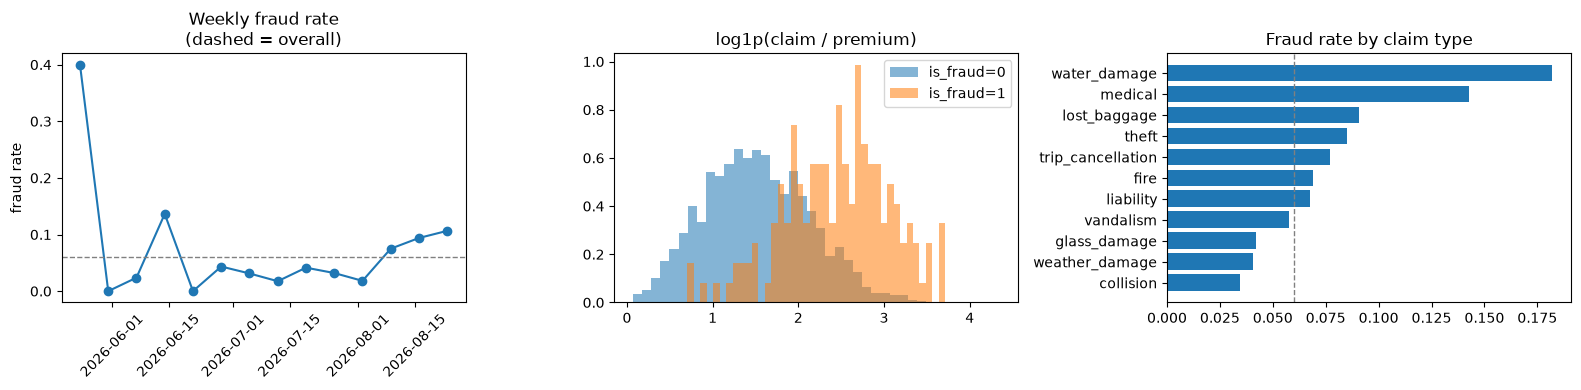

class balance:
is_fraud
legit    2538
fraud     162


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

monthly = (
    training_df.set_index("event_timestamp")
    .resample("W")["is_fraud"]
    .agg(["mean", "count"])
)
axes[0].plot(monthly.index, monthly["mean"], marker="o")
axes[0].axhline(training_df["is_fraud"].mean(), ls="--", c="grey", lw=1)
axes[0].set_title("Weekly fraud rate\n(dashed = overall)")
axes[0].set_ylabel("fraud rate")
axes[0].tick_params(axis="x", rotation=45)

for label, group in training_df.groupby("is_fraud"):
    axes[1].hist(
        np.log1p(group["claim_to_premium_ratio"].dropna()),
        bins=40, alpha=0.55, density=True, label=f"is_fraud={label}",
    )
axes[1].set_title("log1p(claim / premium)")
axes[1].legend()

by_type = training_df.groupby("claim_type")["is_fraud"].mean().sort_values()
axes[2].barh(by_type.index, by_type.values)
axes[2].axvline(training_df["is_fraud"].mean(), ls="--", c="grey", lw=1)
axes[2].set_title("Fraud rate by claim type")

plt.tight_layout()
plt.show()

print("class balance:")
print(training_df["is_fraud"].value_counts().rename({0: "legit", 1: "fraud"}).to_string())

The rising tail in the weekly rate is the generator's simulated drift (§6): in
the last 14 days claim amounts inflate, payments fail more often, and the odds of
fraud double. It is there so §12's drift monitoring has something real to find —
and it is also the reason the split below is by time.

## 6. Train / validation split — by time, not at random

A random split would score better and mean less. Three reasons to cut by date:

1. **Production only ever scores the future.** A random split lets the model
   learn from claims filed *after* the ones it is evaluated on, which is a
   capability it will never have at serving time.
2. **The drift window would leak.** Drift sits in the last 14 days. Split at
   random and drifted rows land in both halves, so the model is told about the
   shift it is supposed to be caught out by, and the score overstates what the
   first day in production will look like.
3. **Customers repeat.** The same customer can file several claims, and
   `customer_90d` features are correlated across them. A random split puts one
   customer's claims on both sides of the line.

The cost is honesty: these numbers are lower than a random split would give, and
they are the ones that predict the first week of serving.

In [9]:
CUTOFF_QUANTILE = 0.8
cutoff = training_df["event_timestamp"].quantile(CUTOFF_QUANTILE)

train_df = training_df[training_df["event_timestamp"] < cutoff]
val_df = training_df[training_df["event_timestamp"] >= cutoff]

print(f"cutoff     : {cutoff.date()}")
print(f"train      : {len(train_df):5d} rows  {train_df['is_fraud'].sum():3d} fraud "
      f"({train_df['is_fraud'].mean():.2%})  "
      f"{train_df['event_timestamp'].min().date()} -> {train_df['event_timestamp'].max().date()}")
print(f"validation : {len(val_df):5d} rows  {val_df['is_fraud'].sum():3d} fraud "
      f"({val_df['is_fraud'].mean():.2%})  "
      f"{val_df['event_timestamp'].min().date()} -> {val_df['event_timestamp'].max().date()}")
print("\nThe validation fraud rate is higher than train — that is the drift, not a bug.")

cutoff     : 2026-08-14
train      :  2118 rows   98 fraud (4.63%)  2026-05-22 -> 2026-08-13
validation :   582 rows   64 fraud (11.00%)  2026-08-14 -> 2026-08-18

The validation fraud rate is higher than train — that is the drift, not a bug.


### Feature selection

Two features are dropped from the model even though the view serves them:

- **`claim_month`** — under a temporal split it is a proxy for the split itself.
  Training sees months 5–7 and validation is month 8, so any weight learned on
  it is unusable by construction. `claim_day_of_week` and `claim_is_weekend`
  stay: they cycle, so they generalize forward.
- **`premium_amount`** is kept, but note it is already inside
  `claim_to_premium_ratio`, so the two are correlated by construction. That
  matters for a linear model specifically: it splits one signal across two
  inputs, which makes the individual coefficients unreliable to read even when
  the predictions are fine. Kept because the raw premium also carries level
  information the ratio throws away — a $500 claim on a $250 premium and a
  $50,000 claim on a $25,000 premium share a ratio and are not the same event.

In [10]:
NUMERIC = [
    "claim_amount",
    "premium_amount",
    "claim_to_premium_ratio",
    "days_since_policy_start",
    "age",
    "claim_day_of_week",
    "f_customer_avg_claim_amount_90d",
    "f_customer_total_claims_90d",
    "f_customer_total_claim_amount_90d",
    "f_customer_total_payments_90d",
    "f_customer_payment_failure_rate_90d",
]
BINARY = ["marketing_opt_in", "claim_is_weekend"]
CATEGORICAL = ["claim_type", "policy_type", "policy_status", "province", "risk_segment"]

MODEL_FEATURES = NUMERIC + BINARY + CATEGORICAL
DROPPED = sorted(set(FEATURE_COLS) - set(MODEL_FEATURES))

print(f"model features : {len(MODEL_FEATURES)}")
print(f"dropped        : {DROPPED}")


def to_matrix(frame: pd.DataFrame) -> pd.DataFrame:
    """Feast returns bools as object; make the dtypes explicit before the pipeline."""
    out = frame[MODEL_FEATURES].copy()
    for col in BINARY:
        out[col] = out[col].astype("boolean").astype("float64")
    for col in CATEGORICAL:
        out[col] = out[col].astype(object)
    return out


X_train, y_train = to_matrix(train_df), train_df["is_fraud"].to_numpy()
X_val, y_val = to_matrix(val_df), val_df["is_fraud"].to_numpy()
print("X_train:", X_train.shape, " X_val:", X_val.shape)

model features : 18
dropped        : ['claim_month']
X_train: (2118, 18)  X_val: (582, 18)


## 7. Train

Preprocessing lives *inside* the estimator, as a `ColumnTransformer`. That is
what makes the saved artifact a model rather than half a model: the prediction
API gets raw feature values from Redis and must not be expected to reproduce an
imputation strategy or a one-hot column order. If preprocessing sat outside the
pipeline, train/serve skew would be a matter of time.

**One model: logistic regression.** It is the baseline, and a baseline is what a
notebook at this stage is for — it establishes whether the signal is there at all
and gives §5 a number to beat. A gradient-boosted model was tried here and scored
within noise of it on a 582-row validation set with 64 positives, which is not
enough evidence to prefer either.

It weights the positive class rather than resampling. At a ~6% base rate,
unweighted training on this many rows converges to predicting "legit" for
everything, which scores ~95% accuracy on the training window and is worthless.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def preprocessor() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline([
                    # Median, not mean: claim amounts are heavy-tailed.
                    ("impute", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler()),
                ]),
                NUMERIC,
            ),
            ("binary", SimpleImputer(strategy="most_frequent"), BINARY),
            (
                "categorical",
                Pipeline([
                    # "unknown" as a category, not a filled-in guess: a null
                    # risk_segment means the column did not exist when that
                    # customer signed up, and that is itself a signal.
                    ("impute", SimpleImputer(strategy="constant", fill_value="unknown")),
                    # handle_unknown="ignore" so a category first seen in
                    # production cannot raise at prediction time.
                    ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]),
                CATEGORICAL,
            ),
        ],
        remainder="drop",
    )


MODEL_NAME = "logistic"

model = Pipeline([
    ("prep", preprocessor()),
    # class_weight="balanced" reweights the loss by inverse class frequency, so the
    # ~1 in 16 fraud cases carry as much weight in total as the majority class.
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
])

model.fit(X_train, y_train)
print(f"fitted {MODEL_NAME} on {len(X_train)} rows, "
      f"{int(y_train.sum())} positives ({y_train.mean():.2%})")

fitted logistic on 2118 rows, 98 positives (4.63%)


## 8. Evaluate

**Accuracy is not reported.** because 6% of the dataset is fraud. So a model could predict every claims as "legit" and still score ~94% accuracy. Thus, accuracy would make a useless model look good.

- **PR-AUC (average precision)** is the headline. It only cares about the
  positive class, which is the one that matters at a 6% base rate.
- **ROC-AUC** for ranking quality and comparability.
- **Precision / recall at a review budget.** Nobody investigates every claim.
  The realistic question is "if a team can review the top 10% of claims by risk,
  what fraction of fraud do they see?"

In [12]:
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

REVIEW_BUDGET = 0.10


scores = model.predict_proba(X_val)[:, 1]
baseline_pr = float(y_val.mean())


def at_budget(budget: float) -> dict:
    """Precision and recall if the team can review the top `budget` share of claims."""
    threshold = float(np.quantile(scores, 1 - budget))
    flagged = scores >= threshold
    tn, fp, fn, tp = confusion_matrix(y_val, flagged, labels=[0, 1]).ravel()
    return {
        "budget": budget,
        "threshold": threshold,
        "reviewed": int(flagged.sum()),
        "precision": float(tp / max(tp + fp, 1)),
        "recall": float(tp / max(tp + fn, 1)),
        "fraud_caught": int(tp),
        "fraud_missed": int(fn),
        "lift_vs_random": float((tp / max(tp + fp, 1)) / baseline_pr),
    }


result = {
    "model": MODEL_NAME,
    "pr_auc": float(average_precision_score(y_val, scores)),
    "roc_auc": float(roc_auc_score(y_val, scores)),
    **at_budget(REVIEW_BUDGET),
}

print(f"validation: {len(y_val)} claims, {int(y_val.sum())} fraud ({baseline_pr:.2%})")
print(f"a random ranker scores PR-AUC {baseline_pr:.3f}\n")
print(f"PR-AUC  {result['pr_auc']:.3f}")
print(f"ROC-AUC {result['roc_auc']:.3f}")

# The whole tradeoff curve, not one point on it. How much fraud gets caught is a
# staffing decision as much as a modelling one, and a single number hides that.
print("\nprecision / recall by review budget:")
print(
    pd.DataFrame([at_budget(b) for b in (0.05, 0.10, 0.20, 0.30)])
    .assign(budget=lambda d: (d["budget"] * 100).astype(int).astype(str) + "%")
    .set_index("budget")[["reviewed", "fraud_caught", "precision", "recall", "lift_vs_random"]]
    .to_string(float_format=lambda v: f"{v:.3f}")
)

validation: 582 claims, 64 fraud (11.00%)
a random ranker scores PR-AUC 0.110

PR-AUC  0.358
ROC-AUC 0.751

precision / recall by review budget:
        reviewed  fraud_caught  precision  recall  lift_vs_random
budget                                                           
5%            30            16      0.533   0.250           4.850
10%           59            21      0.356   0.328           3.237
20%          117            31      0.265   0.484           2.409
30%          175            39      0.223   0.609           2.027


### Metric explanation 
PR-AUC — "how good is the model at sorting fraud to the top of the pile?"

Imagine you take every claim, sort them from "model thinks this is MOST likely fraud" down to "model thinks this is LEAST likely fraud." Now imagine you start reading down that sorted list. A great model puts almost all the real fraud cases near the top and almost all the legit ones near the bottom. A bad model shuffles them randomly.

PR-AUC is just a single number, 0 to 1, that scores "how good was that sorting job":

1.0 = perfect — every single fraud case sits above every single legit case.
Close to your fraud rate (like ~0.06 if 6% of claims are fraud) = basically useless — the model's sorting is no better than shuffling the deck.
Somewhere in between = how much better than random shuffling it's doing.
It doesn't care where you draw the line ("review the top 10%" vs "top 20%") — it just grades the sorting itself, across every possible cutoff at once.

Fraud-flag rate — "out of everyone, what % did the model point a finger at?"

Dead simple: if 1,000 claims come in and the model says "investigate these 100," the flag rate is 10%.

That's it. It's not asking "were those 100 actually fraud" — it's just counting how many got flagged, period. It's a headcount, not a grade.

Why you'd care about a plain headcount: if today the model flags 10% of claims, and tomorrow — after you swap in a new version — it suddenly flags 40%, something changed in a big way, even before anyone checks whether the new flags are correct. That's useful precisely because you can see it instantly, without waiting weeks for investigators to confirm who was actually fraudulent.



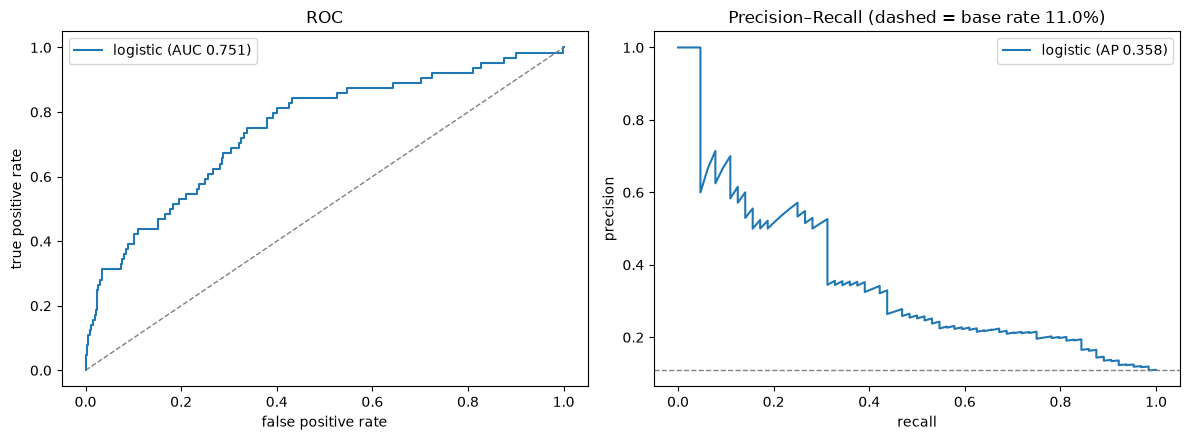

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

fpr, tpr, _ = roc_curve(y_val, scores)
axes[0].plot(fpr, tpr, label=f"{MODEL_NAME} (AUC {result['roc_auc']:.3f})")
precision, recall, _ = precision_recall_curve(y_val, scores)
axes[1].plot(recall, precision, label=f"{MODEL_NAME} (AP {result['pr_auc']:.3f})")

axes[0].plot([0, 1], [0, 1], ls="--", c="grey", lw=1)
axes[0].set(xlabel="false positive rate", ylabel="true positive rate", title="ROC")
axes[0].legend()

axes[1].axhline(baseline_pr, ls="--", c="grey", lw=1)
axes[1].set(xlabel="recall", ylabel="precision",
            title=f"Precision–Recall (dashed = base rate {baseline_pr:.1%})")
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
print(f"at a {REVIEW_BUDGET:.0%} review budget the model flags {result['reviewed']} claims, "
      f"catching {result['fraud_caught']} of "
      f"{result['fraud_caught'] + result['fraud_missed']} fraud")
print(f"  precision {result['precision']:.1%}  recall {result['recall']:.1%}  "
      f"lift vs random {result['lift_vs_random']:.1f}x")
# The number accuracy would have reported, printed once so it cannot be mistaken
# for a result: this is what a model that never predicts fraud scores.
print(f"\nfor contrast, a 'never fraud' model scores accuracy "
      f"{1 - baseline_pr:.1%} and catches 0 of {int(y_val.sum())} fraud")

at a 10% review budget the model flags 59 claims, catching 21 of 64 fraud
  precision 35.6%  recall 32.8%  lift vs random 3.2x

for contrast, a 'never fraud' model scores accuracy 89.0% and catches 0 of 64 fraud


### Is this good? — reading the numbers correctly

The most common way to misread this model is to look at precision and call it
accuracy. They are different questions, and only one of them is worth asking here.

**Accuracy is ~89%, and it is meaningless.** A model that labels every single
claim "legit" scores 89% on this validation set, because 89% of claims *are*
legit. It would catch zero fraud. Any metric a do-nothing model can win is not
measuring the thing we care about, which is why accuracy is not reported above.

**Precision at a review budget is the number that matters.** At a 10% budget the
model is right about roughly 1 flagged claim in 3, against 1 in 9 for reviewing
claims at random — the same investigator hours find about three times as much
fraud. That is what the model is *for*: it does not decide anything, it decides
what a human looks at first.

**Recall is the other half.** Catching a third of fraud while inspecting a tenth
of claims is the tradeoff at this budget; the table above shows what widening the
budget buys. Which point to pick is a staffing decision — the model just supplies
the ordering.

So the honest summary: **the ranking works and is well clear of random, and the
absolute ceiling is limited by the data, not the algorithm.** Three concrete
limits, in the order they cost the most:

1. **A real driver is unobservable.** The label generator uses the customer's true
   `risk_segment`, and roughly two thirds of claims have it null because of the
   simulated schema change. No model can recover a column that is not there.
2. **64 positives in validation.** Every metric here has wide error bars. A
   couple of claims moving across the threshold shifts precision by several
   points, which is also why swapping in a fancier algorithm proved nothing.
3. **No behavioural history to speak of.** Most claimants have no prior claim in
   their 90-day window, so the customer aggregates are mostly zero. Streaming
   features (`feat_stream_30m`) are the intended fix and need Kafka/Flink first.

None of those is fixed by a different estimator, which is the argument for keeping
this notebook's model simple and putting the effort into features.

### Which features carry it

Read as a sanity check on the data, not as an explanation of fraud. What we want
to see is the model leaning on the drivers the generator actually used —
claim-to-premium ratio, claim type, days since policy start, risk segment. If it
instead leaned on something like `province`, that would point at a join bug
rather than a discovery.

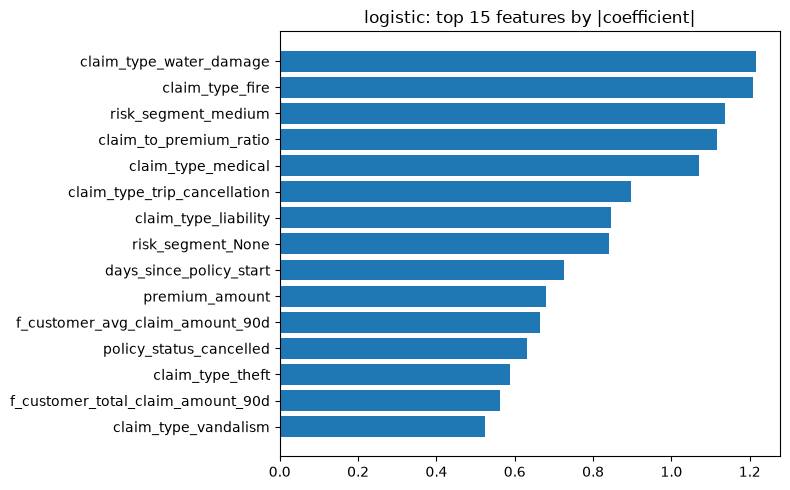

In [15]:
names = model.named_steps["prep"].get_feature_names_out()
clf = model.named_steps["clf"]

# Absolute coefficient on standardised inputs, so the magnitudes are comparable
# across features that live on completely different scales (dollars vs. day-of-week).
# Sign is dropped deliberately: this asks "how much does the model lean on this",
# not "which direction", and the direction of a one-hot level is not interesting.
importance = pd.Series(np.abs(clf.coef_[0]), index=names)

top = importance.sort_values(ascending=False).head(15)[::-1]
plt.figure(figsize=(8, 5))
plt.barh([n.split("__", 1)[-1] for n in top.index], top.values)
plt.title(f"{MODEL_NAME}: top 15 features by |coefficient|")
plt.tight_layout()
plt.show()

## 9. Save the artifact

One file, containing the fitted pipeline *and* the metadata needed to reproduce
and to serve it:

- the **feature list in order**, so the prediction API knows exactly which keys
  to read from Redis
- the **data version** and training window, so a result can be traced back
- the **validation metrics and operating point**, so a later model has something
  to beat and the API has a default threshold

Saving the whole `Pipeline` rather than the bare booster is deliberate: the
estimator alone would need its imputers, scaler and one-hot column order rebuilt
by hand at serving time, and any drift between the two implementations is
train/serve skew that no test would catch.

In §5 this same bundle is logged to MLflow instead, and the registry's
`Production` pointer is what KServe resolves at serving time. `.joblib` on disk
is the notebook's deliverable, not the deployment path.

In [16]:
MODEL_DIR = REPO / "models"
MODEL_DIR.mkdir(exist_ok=True)
artifact_path = MODEL_DIR / "fraud_model.joblib"

bundle = {
    "model": model,
    "model_type": MODEL_NAME,
    "features": {"numeric": NUMERIC, "binary": BINARY, "categorical": CATEGORICAL},
    "feature_views": CLAIM_FEATURES + CUSTOMER_FEATURES,
    "excluded_features": DROPPED,
    "label": "is_fraud",
    "data_version": data_version,
    "training_window": {
        "train_start": str(train_df["event_timestamp"].min().date()),
        "train_end": str(train_df["event_timestamp"].max().date()),
        "val_start": str(val_df["event_timestamp"].min().date()),
        "val_end": str(val_df["event_timestamp"].max().date()),
        "split": f"temporal, quantile {CUTOFF_QUANTILE}",
    },
    "metrics": result,
    "budget_curve": [at_budget(b) for b in (0.05, 0.10, 0.20, 0.30)],
    "operating_point": {"review_budget": REVIEW_BUDGET, "threshold": result["threshold"]},
}

joblib.dump(bundle, artifact_path)
print(f"saved {artifact_path.relative_to(REPO)} "
      f"({artifact_path.stat().st_size / 1024:.0f} KB)")

# Metadata beside the artifact so it is readable without loading pickled objects.
metadata_path = MODEL_DIR / "fraud_model.metadata.json"
metadata_path.write_text(
    json.dumps({k: v for k, v in bundle.items() if k != "model"}, indent=2, default=str)
)
print(f"saved {metadata_path.relative_to(REPO)}")

saved models/fraud_model.joblib (9 KB)
saved models/fraud_model.metadata.json


### Reload and check

A saved model that cannot be loaded and scored in a fresh object is not a
deliverable. This is also the property §9 tests with `hypothesis`: the same input
must produce the same prediction every time.

In [17]:
reloaded = joblib.load(artifact_path)
sample = X_val.head(5)

original = model.predict_proba(sample)[:, 1]
restored = reloaded["model"].predict_proba(sample)[:, 1]

assert np.allclose(original, restored), "reloaded model does not reproduce predictions"
print("reloaded predictions match:", np.round(restored, 4))

reloaded predictions match: [0.2867 0.2614 0.1453 0.1627 0.2756]


/home/qmai/FSDS/coursework/insurance_ai_de_engineering_project/.venv-ml/lib/python3.12/site-packages/joblib/numpy_pickle.py:207: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  array.shape = self.shape


## 10. What this hands to the next steps

| Next | What it takes from here |
|---|---|
| §5 Kubeflow pipeline | these steps as components, plus distributed XGBoost; every run logged to MLflow |
| §7 versioning | `data_version` becomes an MLflow tag; the model goes to the registry instead of `models/` |
| §1 `fraud-prediction-api` | `features` gives the exact Redis read list; `operating_point.threshold` the default cutoff |
| §9 validation | the reload check above becomes the property-based idempotency test |
| §12 / §13 | validation PR-AUC and the fraud-flag rate are the baseline a challenger is compared against |

Known limits, stated rather than discovered later:

- **Small positive class.** The validation set holds a few dozen fraud cases, so
  the metrics have wide error bars. Cross-validation over rolling time windows is
  the fix, and belongs in the pipeline where it can be run repeatedly.
- **No streaming features.** `feat_stream_30m` does not exist yet (Kafka/Flink is
  still pending), so the model sees no near-real-time signal. Adding it later
  requires Job 1 to have been writing to the offline store first, or the feature
  is untrainable — the train/serve skew argument in `docs/feature_store.md`.
- **Labels are synthetic and generated from a known formula.** The signal is real
  but the ceiling is artificial; these numbers say the plumbing is sound, not
  that fraud detection is solved.